In [1]:
import numpy as np
import xarray as xr
import json
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut
import torch
import importlib
import matplotlib.pyplot as plt

In [2]:
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v6_dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)

settings_file_path_ERA5 = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v5_dpa_train_settings_ERA5.json"
with open(settings_file_path_ERA5, 'r') as file:
        settings_ERA5 = json.load(file)

In [9]:
# Load dataset
#ds_pre = xr.open_dataset(settings_ERA5['dataset_trefht_eth_transient'])
#print(settings_ERA5['dataset_trefht_eth_transient'])

# Rename variable
#ds = ds_pre.rename({"var167": "TREFHT"})

# Save to new NetCDF file
#ds.to_netcdf("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/v5_starting16012026/new_ERA5_europe_10percent_masked_stacked_TREFHT_JJA.nc")

# Close file handles
#ds.close()
#ds

## Large Ensemble Data

In [3]:
ds_trefht = xr.open_dataset(settings['dataset_trefht'])
ds_trefht

<xarray.Dataset> Size: 2GB
Dimensions:  (lat: 32, lon: 32, time: 476900)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 2GB ...

In [4]:
ds_z500 = xr.open_dataset(settings['dataset_z500'])
ds_z500

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 476900, mode: 1001)
Coordinates:
  * time        (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
  * mode        (mode) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999 1000
Data variables:
    pseudo_pcs  (time, mode) float32 2GB ...

## ETH Data

In [5]:
eth_trefht = xr.open_dataset(settings['dataset_trefht_eth_transient'])
eth_trefht

<xarray.Dataset> Size: 59MB
Dimensions:  (lat: 32, lon: 32, time: 14307)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 59MB ...

In [7]:
eth_z500 = xr.open_dataset(settings['dataset_z500_eth_test'])
eth_z500

<xarray.Dataset> Size: 57MB
Dimensions:     (time: 14307, mode: 1001)
Coordinates:
  * time        (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
  * mode        (mode) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999 1000
Data variables:
    pseudo_pcs  (time, mode) float32 57MB ...

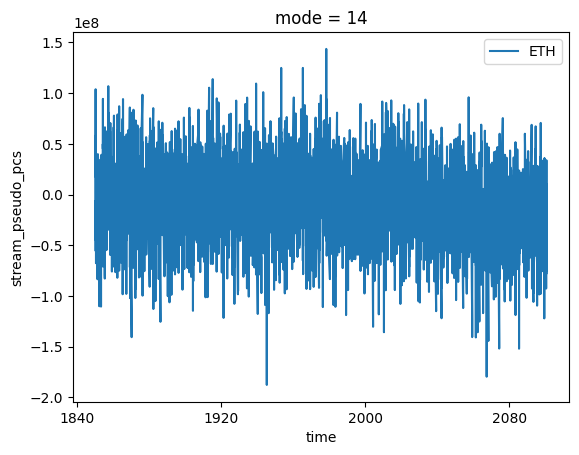

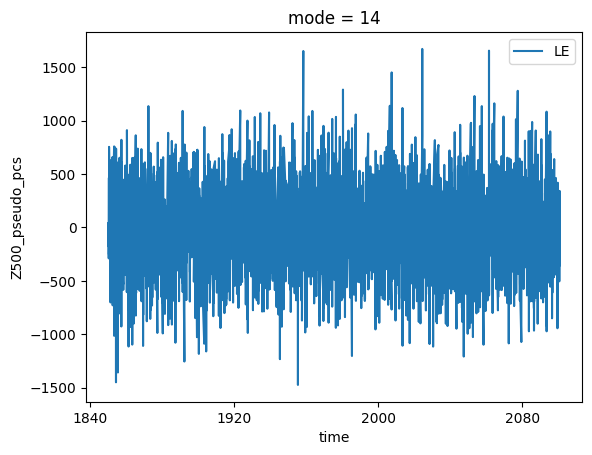

In [24]:
# plot all
mode=14
eth_z500.pseudo_pcs.isel(mode=mode, time=slice(0,4769)).plot(label="ETH")
plt.legend()
plt.show()
ds_z500.pseudo_pcs.isel(mode=mode, time=slice(0,4769)).plot(label="LE")
plt.legend()
plt.show()


## ERA5 Data

In [7]:
ERA5_trefht = xr.open_dataset()#(settings_ERA5["dataset_trefht_eth_transient"])
ERA5_nudged = xr.open_dataset()#(settings_ERA5["dataset_trefht_eth_nudged_shifted"])

ERA5_trefht

<xarray.Dataset> Size: 7MB
Dimensions:  (lat: 32, lon: 32, time: 1596)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 13kB 1940-06-02 11:30:00 ... 2023-08-31 11:30:00
Data variables:
    TREFHT   (lat, lon, time) float32 7MB ...

In [8]:
ERA5_nudged

<xarray.Dataset> Size: 7MB
Dimensions:  (time: 1615, lat: 32, lon: 32)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 13kB 1940-06-02 00:00:00 ... 2024-08-31 00:00:00
Data variables:
    TREFHT   (time, lat, lon) float32 7MB ...

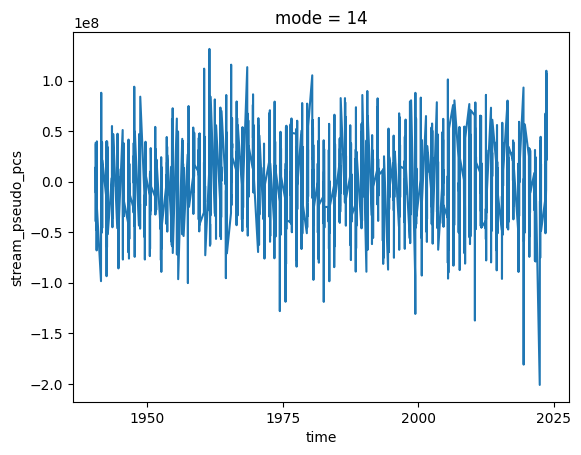

In [25]:
ERA5_z500 = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/v6_starting03022026/pcsts_and_fGMT_not_standardized_ERA5.nc")#(settings_ERA5["dataset_z500_eth_test"])
ERA5_z500

ERA5_z500.pseudo_pcs.isel(mode=mode).plot()

0


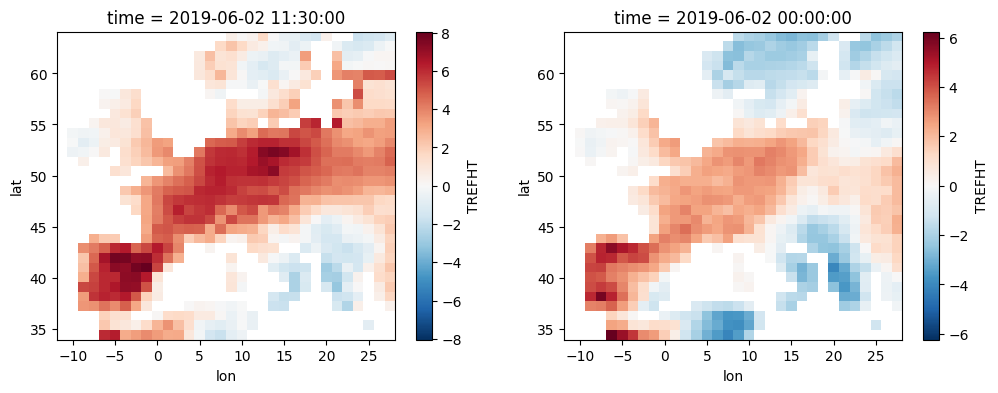

1


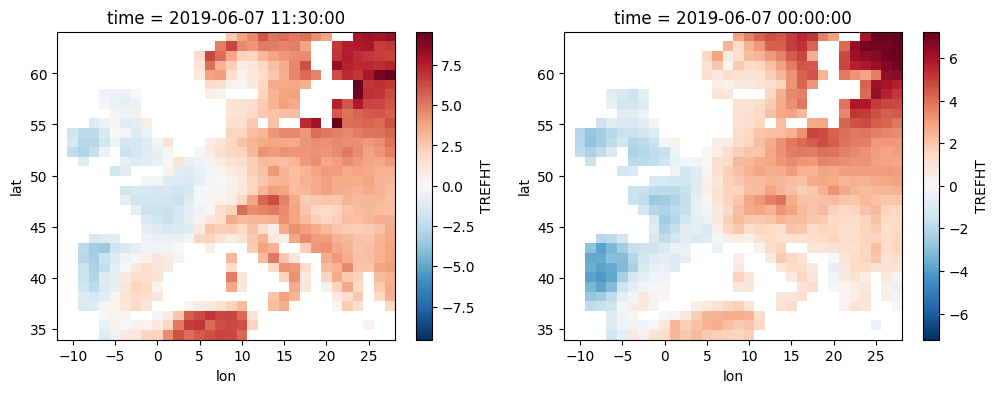

2


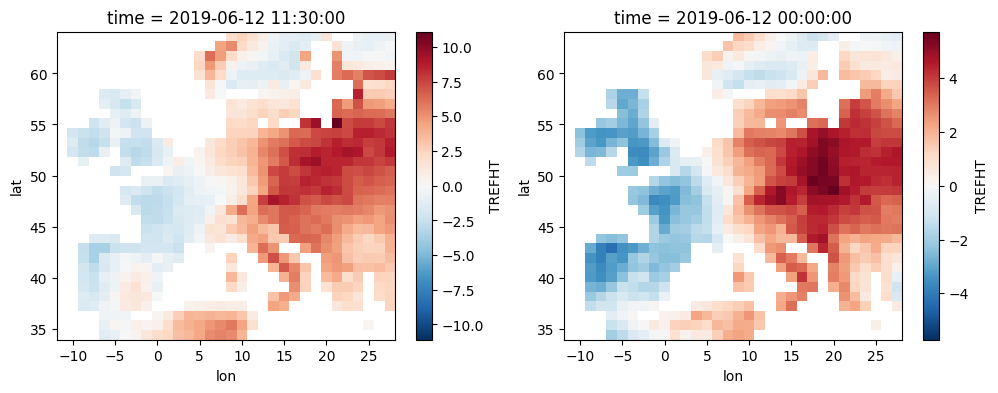

3


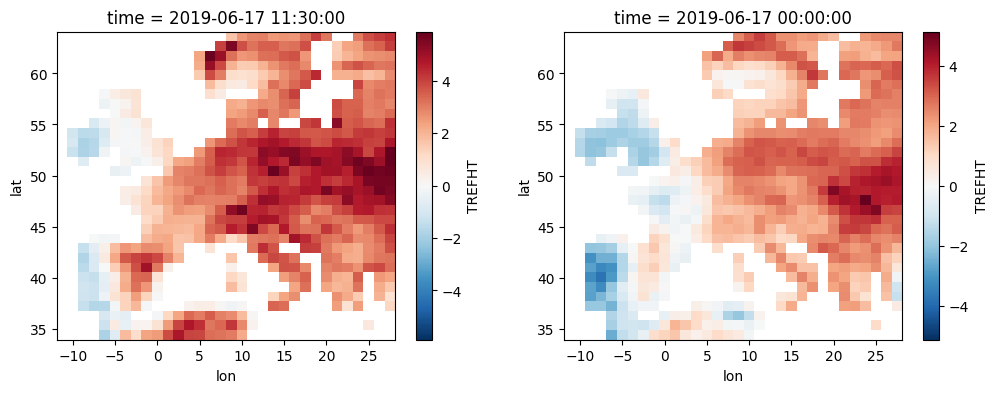

4


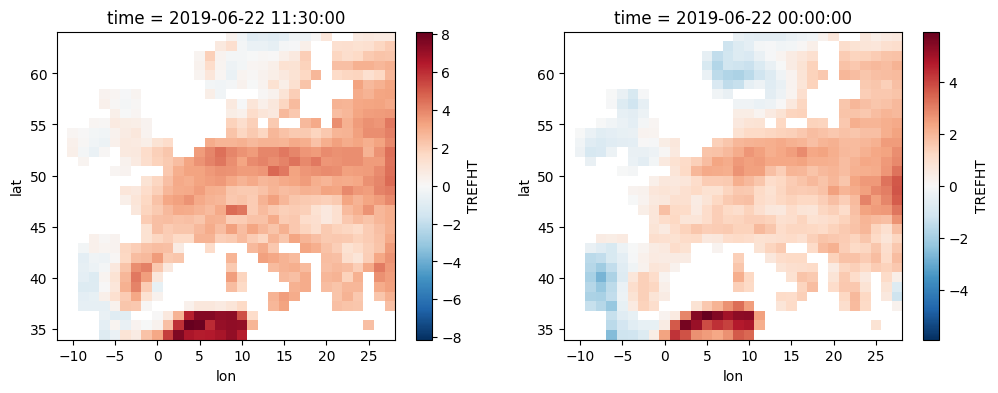

5


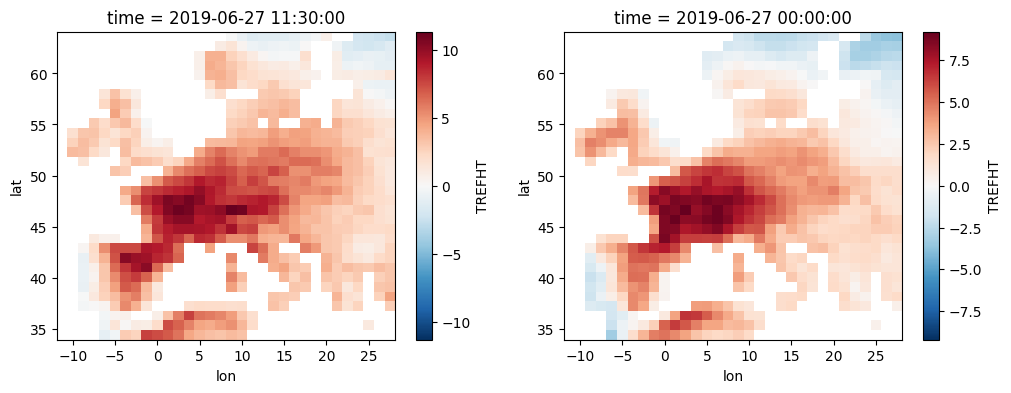

6


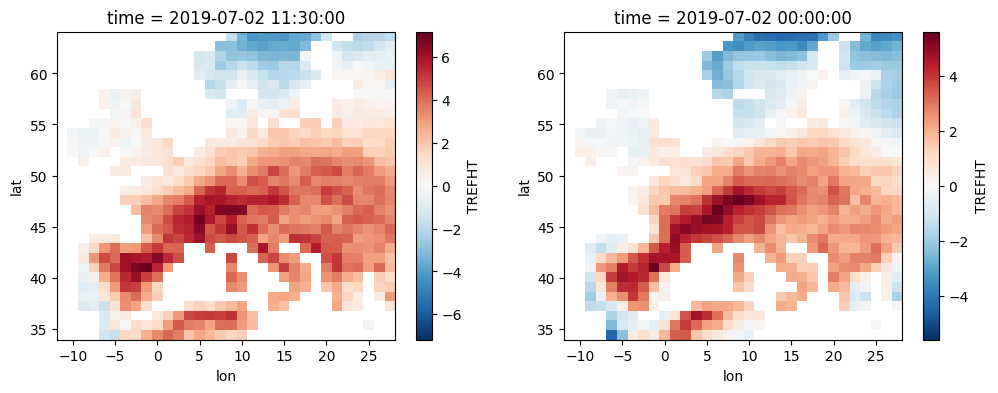

7


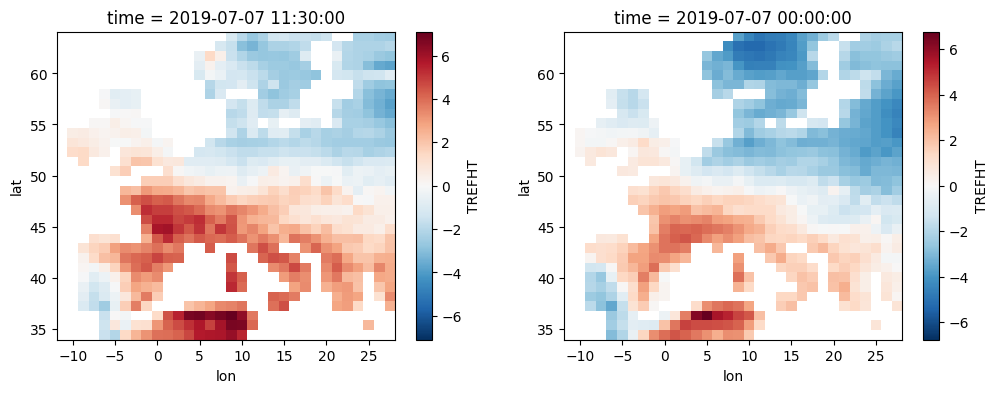

8


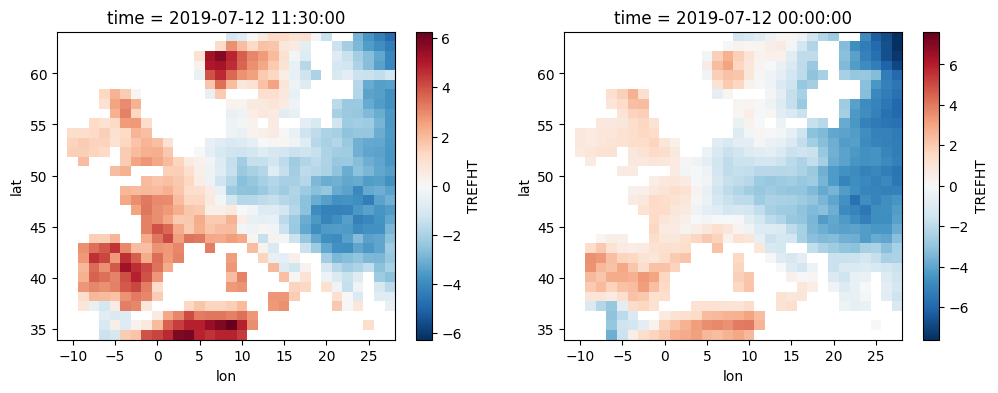

9


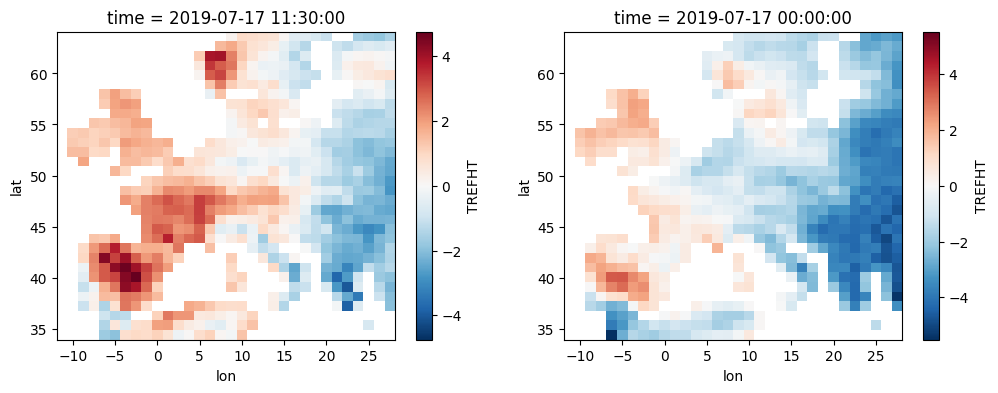

10


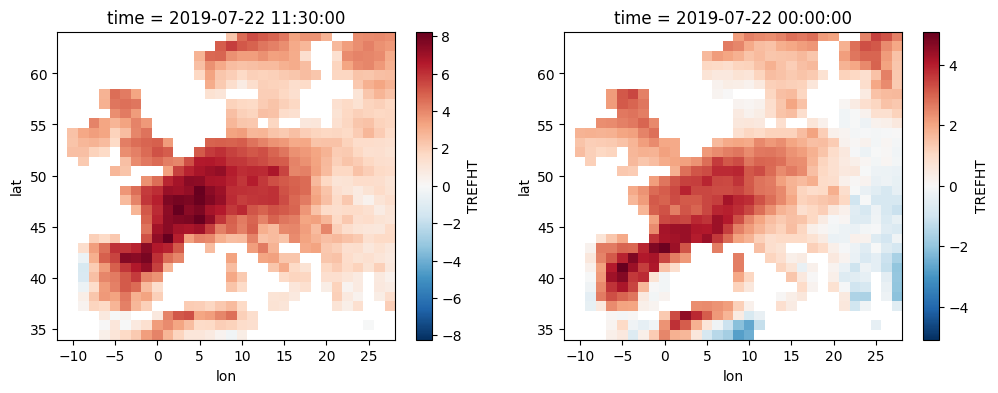

11


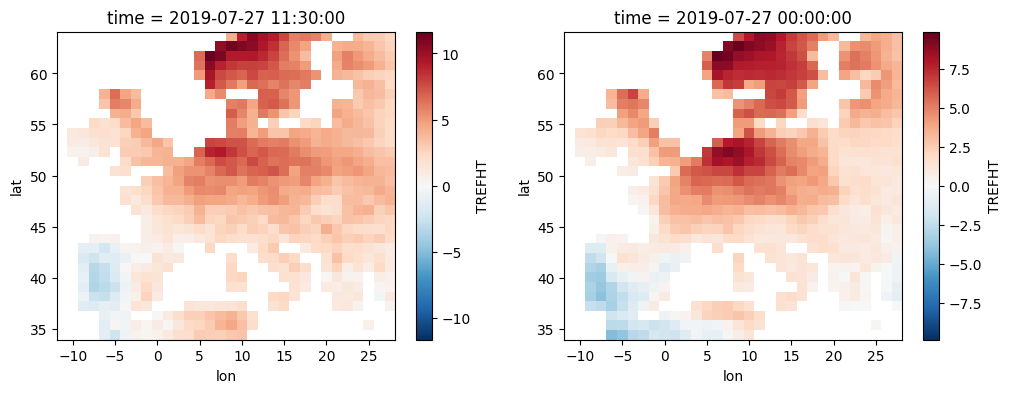

12


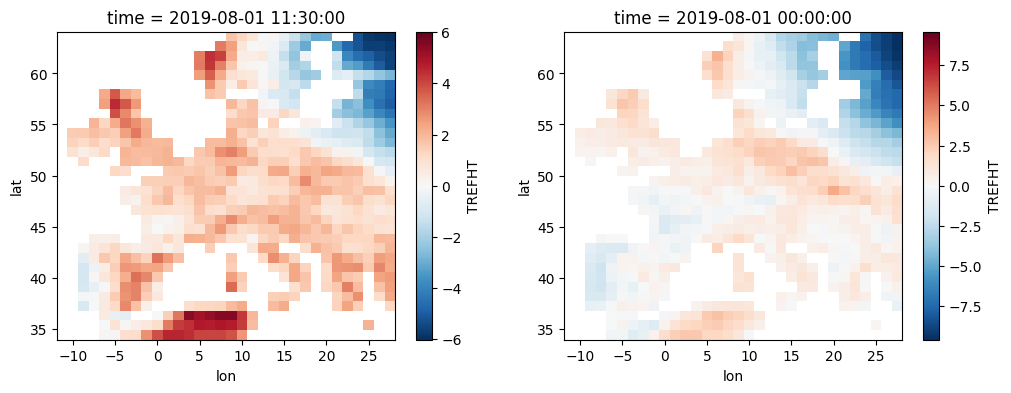

13


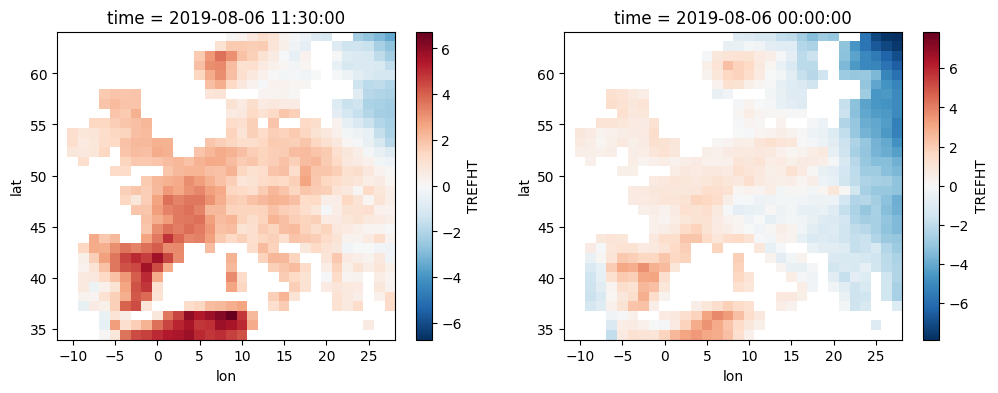

14


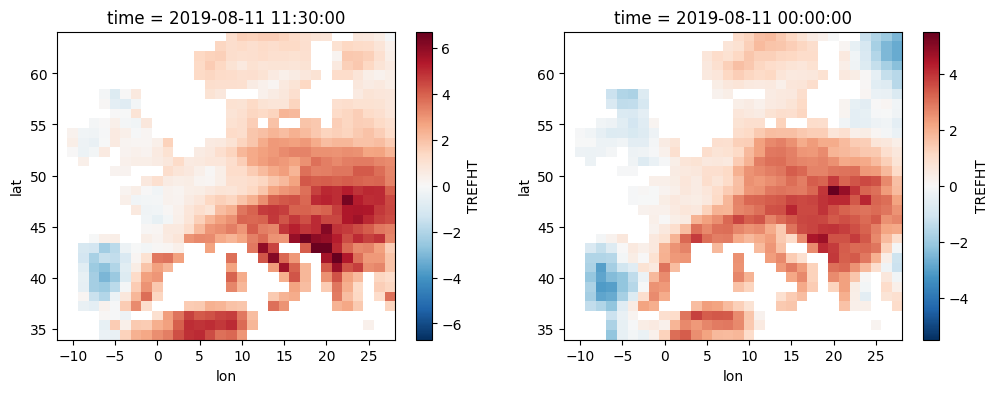

15


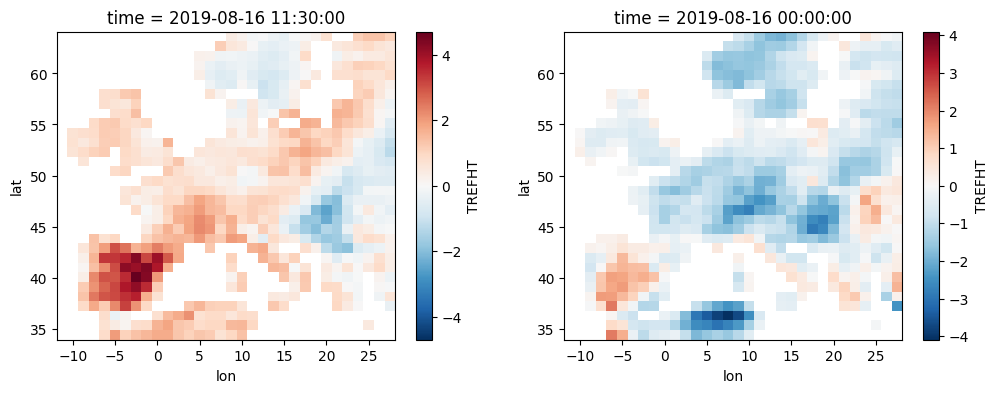

16


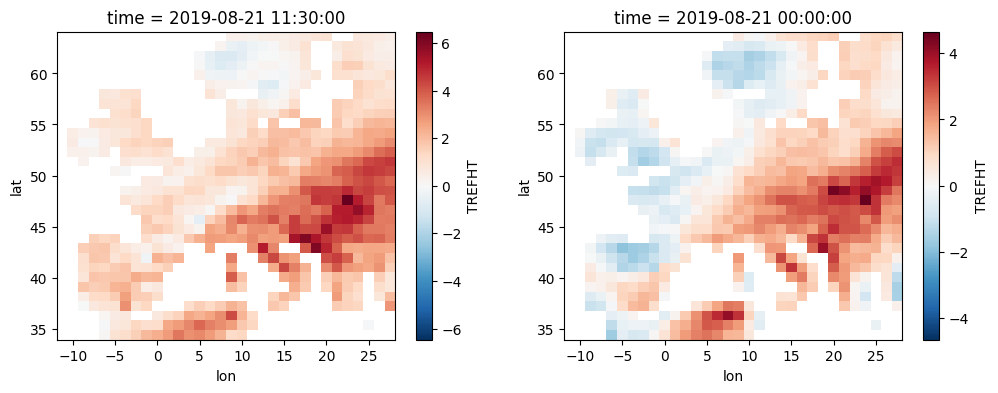

17


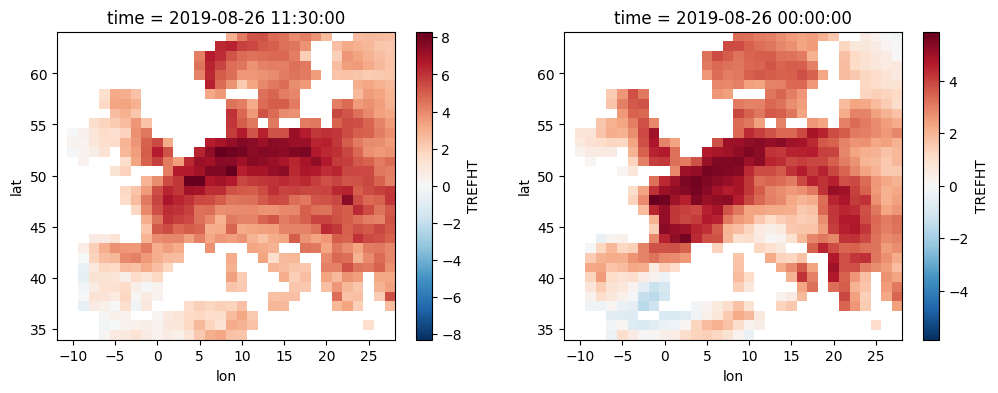

18


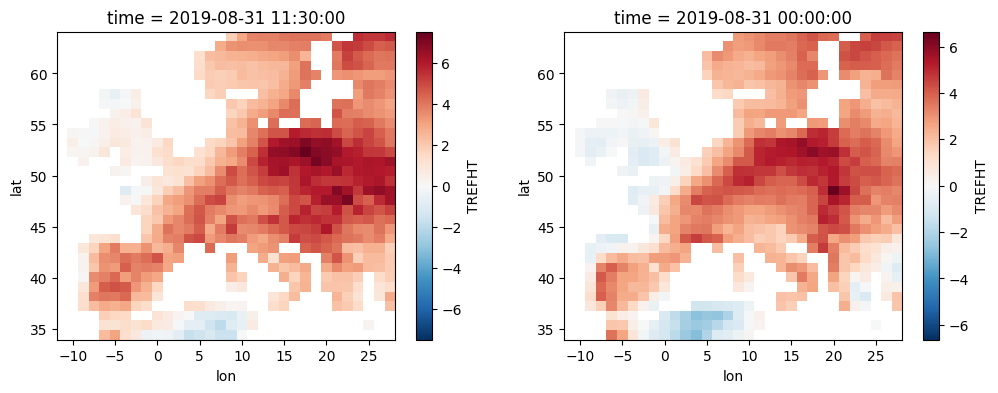

In [38]:
for t in range(19):
    print(t)
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    ERA5_trefht.TREFHT.sel(time="2019").isel(time=t).plot(ax=ax[0])
    ERA5_nudged.TREFHT.sel(time="2019").isel(time=t).plot(ax=ax[1])
    plt.show()

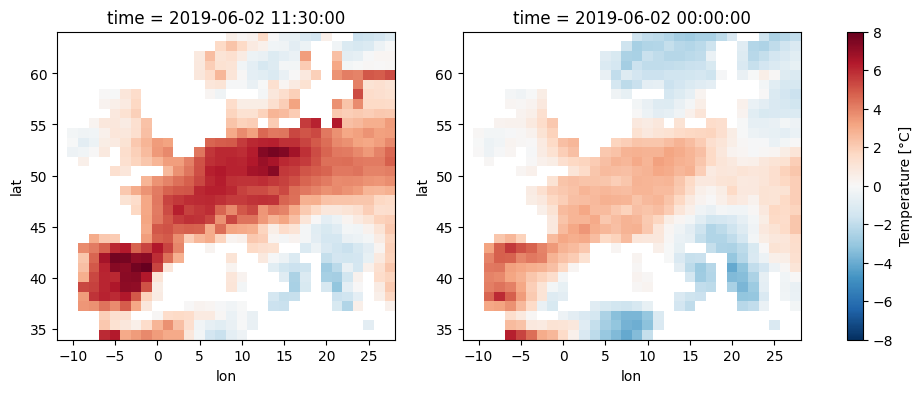

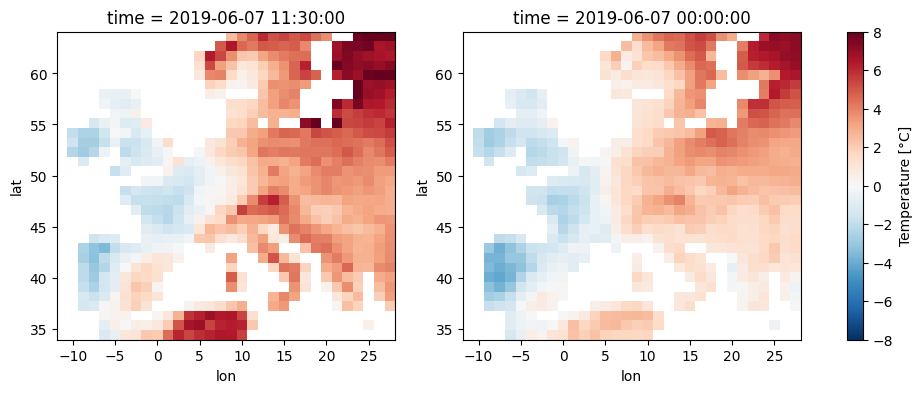

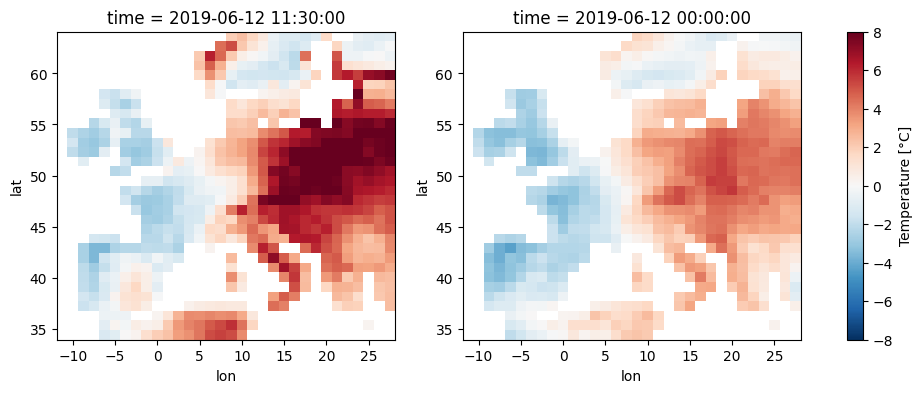

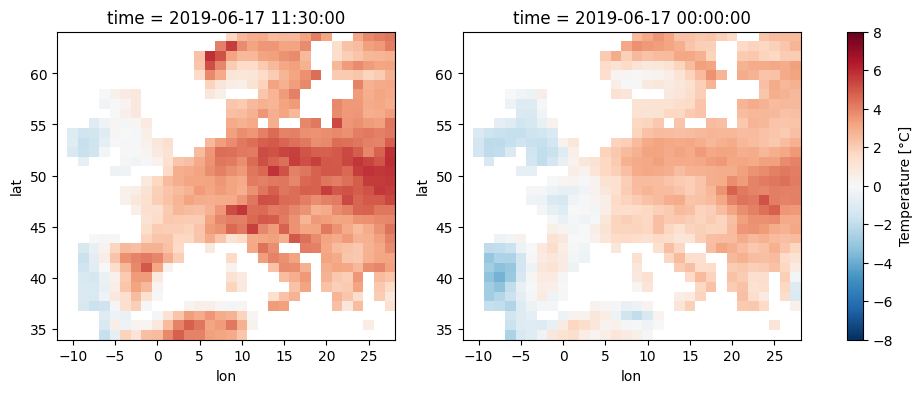

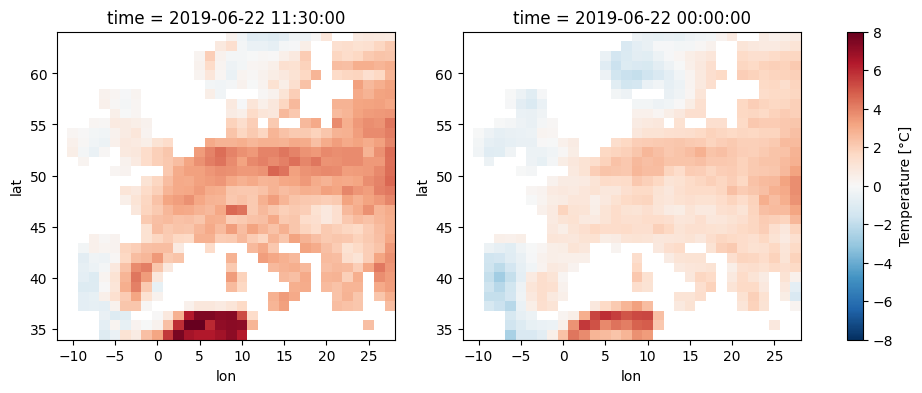

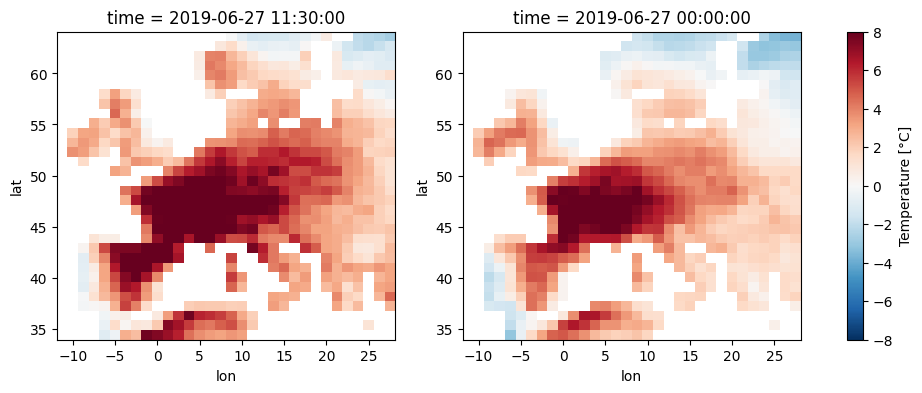

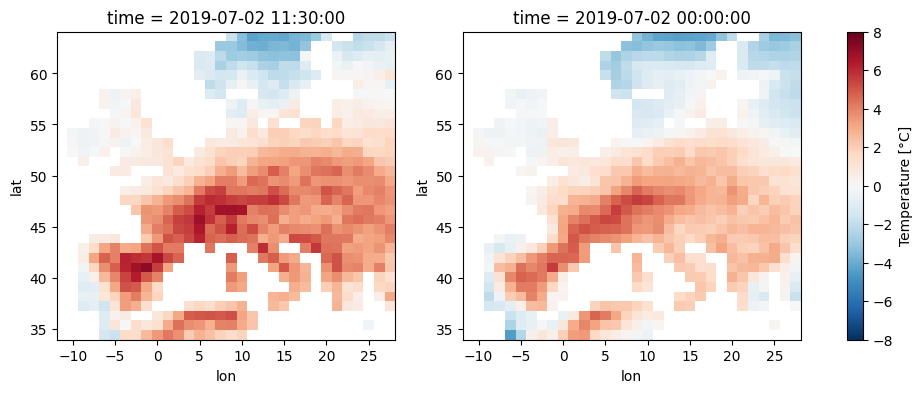

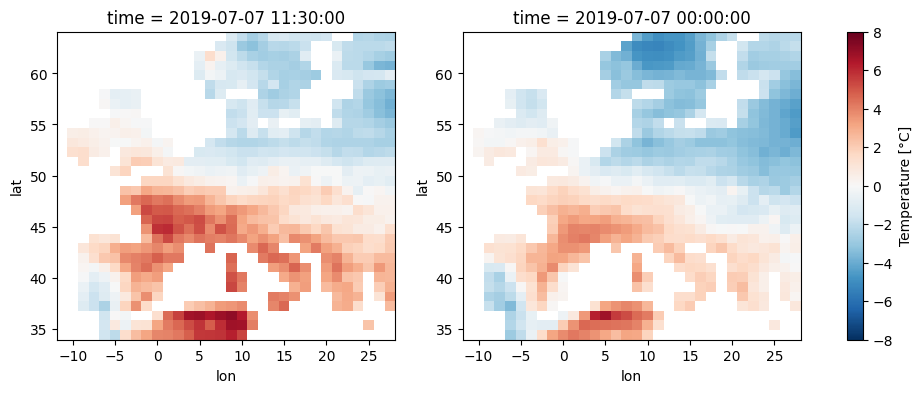

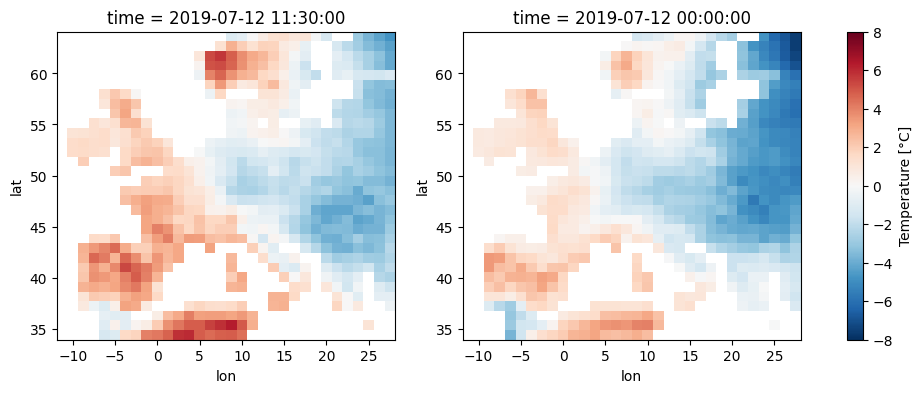

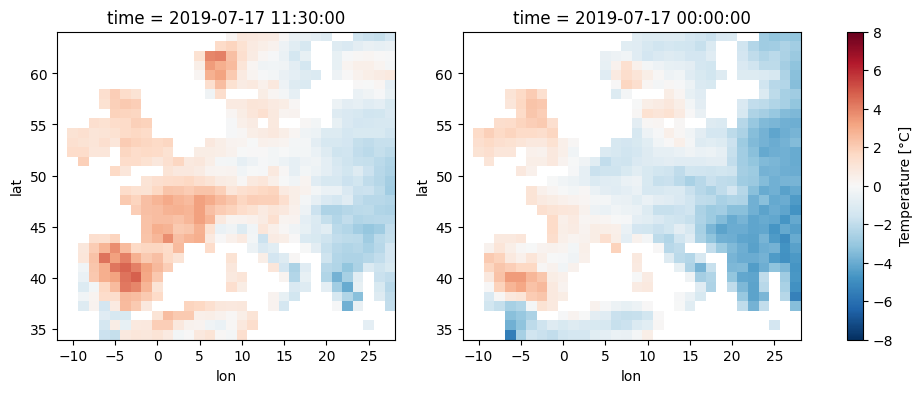

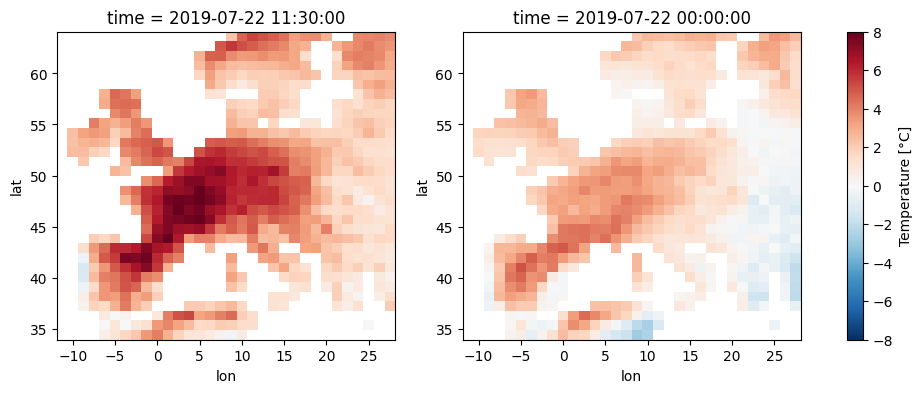

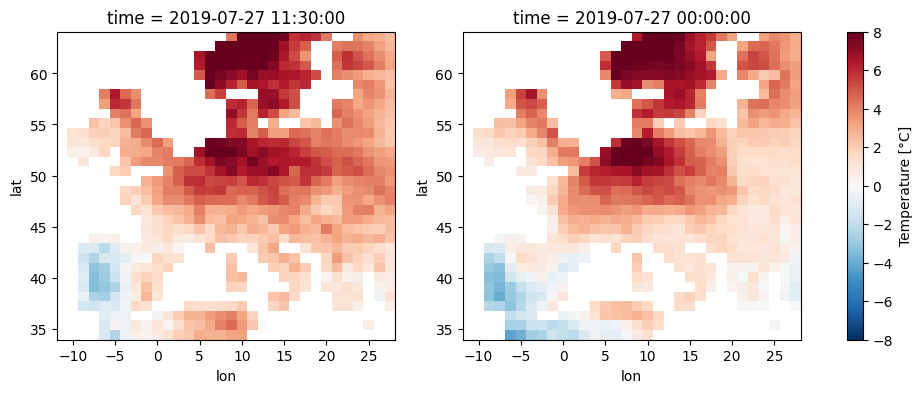

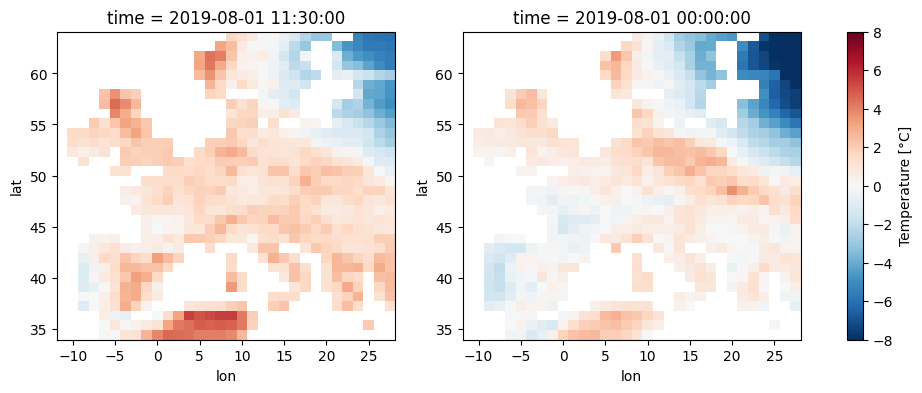

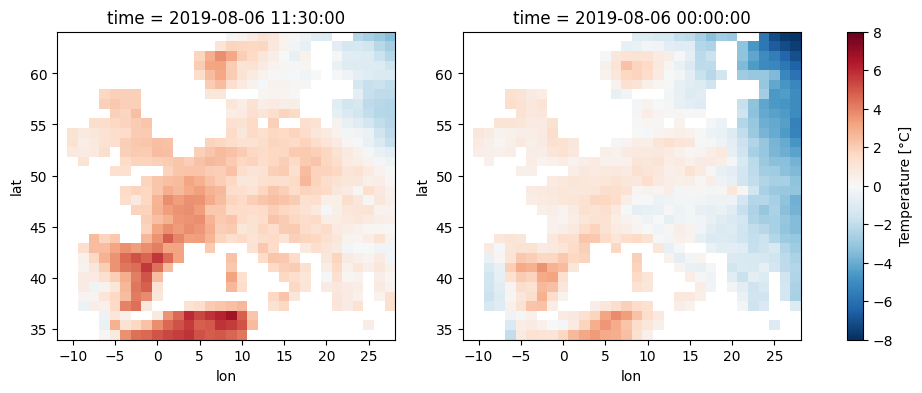

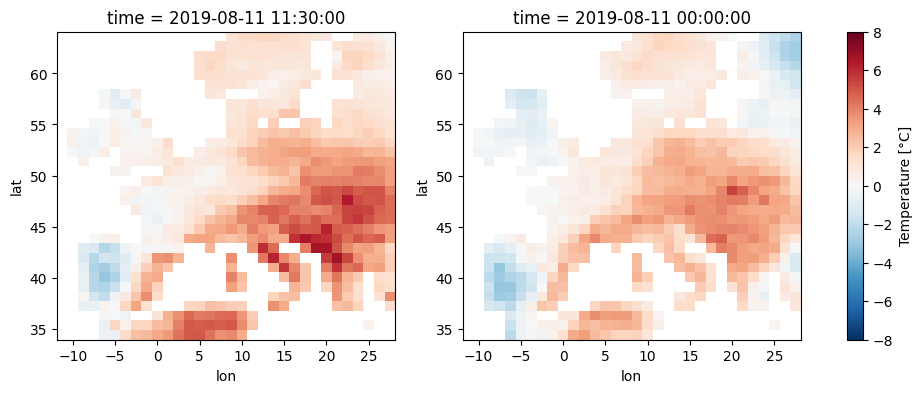

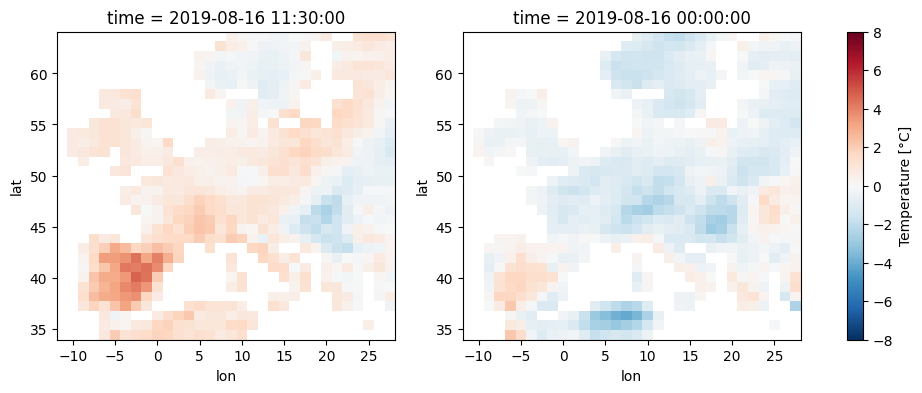

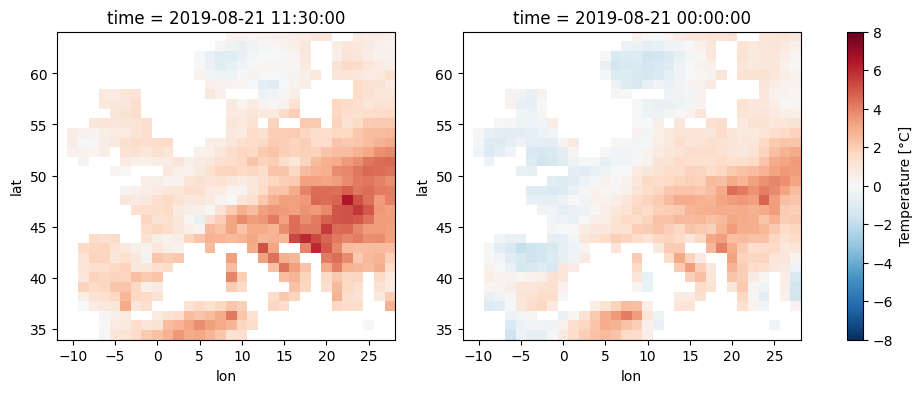

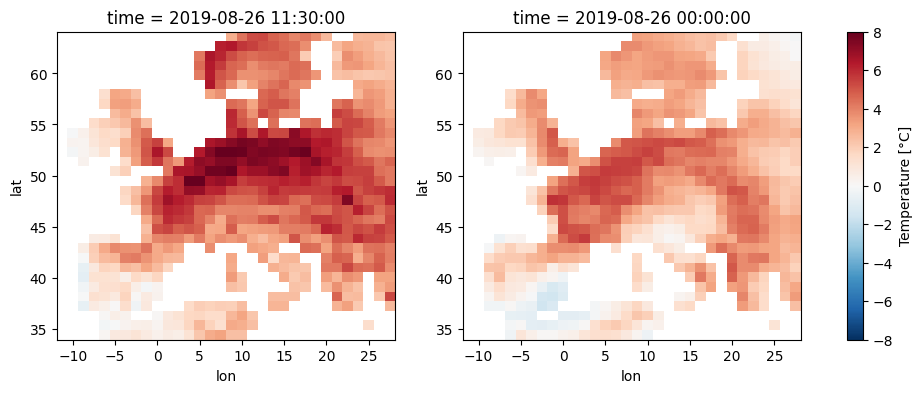

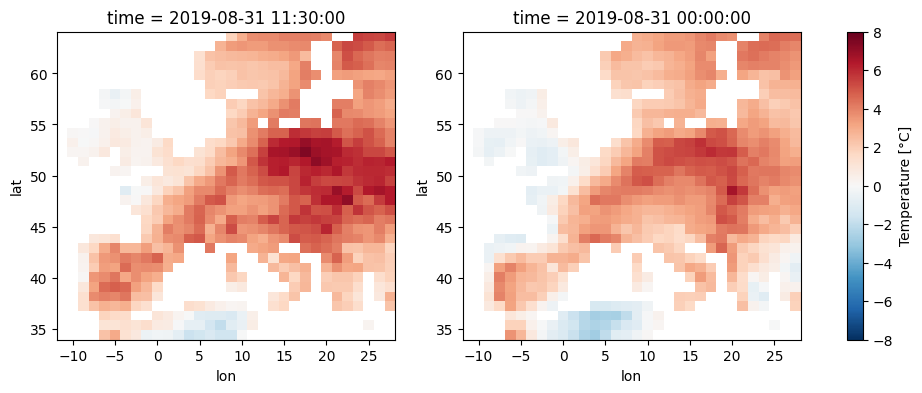

In [41]:
vmin = -8
vmax = 8

for t in range(19):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    p1 = ERA5_trefht.TREFHT.sel(time="2019").isel(time=t).plot(
        ax=ax[0], vmin=vmin, vmax=vmax, cmap="RdBu_r", add_colorbar=False
    )

    ERA5_nudged.TREFHT.sel(time="2019").isel(time=t).plot(
        ax=ax[1], vmin=vmin, vmax=vmax, cmap="RdBu_r", add_colorbar=False
    )

    cbar = fig.colorbar(p1, ax=ax, orientation="vertical")
    cbar.set_label("Temperature [°C]")

    plt.show()


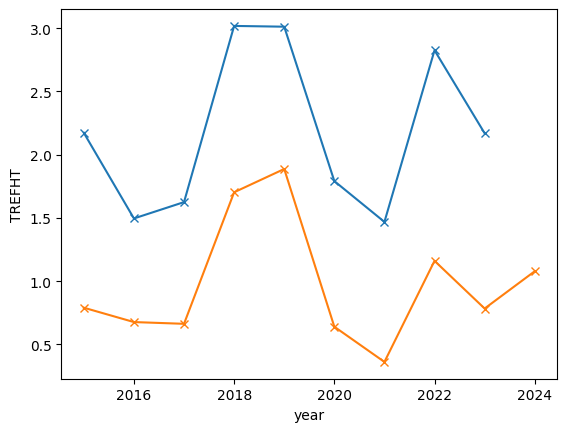

In [69]:
trefht_test_ger_mean = ut.get_ger_1d_data(ERA5_trefht.TREFHT)
trefht_test_ger_mean_era5_nudged = ut.get_ger_1d_data(ERA5_nudged.TREFHT)
trefht_test_ger_mean.sel(time=slice("2015","2024")).groupby("time.year").mean().plot(marker="x")
trefht_test_ger_mean_era5_nudged.sel(time=slice("2015","2024")).groupby("time.year").mean().plot(marker="x")

In [48]:
v4_LE_z500 = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/v4_starting08122025/LE_GMT_and_pseudoPCs_EOFs_Z500_5daily_100ensmembers_JJA_not_scaled.nc")
v4_LE_z500

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 476900, mode: 1001)
Coordinates:
  * time        (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
  * mode        (mode) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999 1000
Data variables:
    pseudo_pcs  (time, mode) float32 2GB ...

### Reference 1950-1980
v5 -2.8334974e-09
v4 0.08748785
### Reference 1850-1900
v5 -0.08748785
v4 1.476276e-09


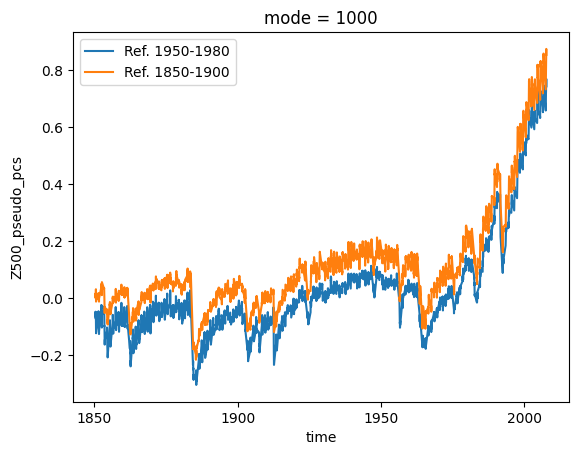

In [61]:
eth_z500.pseudo_pcs.isel(mode=1000).isel(time=slice(0,3000)).plot(label="Ref. 1950-1980")
#ds_z500.pseudo_pcs.isel(mode=1000).isel(time=slice(0,3000)).plot()
#ERA5_z500.pseudo_pcs.isel(mode=1000).isel(time=slice(0,2000)).plot()
v4_LE_z500.pseudo_pcs.isel(mode=1000).isel(time=slice(0,3000)).plot(label="Ref. 1850-1900")
plt.legend()

print("### Reference 1950-1980")
print("v5", eth_z500.pseudo_pcs.isel(mode=1000).isel(time=slice(0,4769)).sel(time=slice("1950","1980")).mean().values)
print("v4", v4_LE_z500.pseudo_pcs.isel(mode=1000).isel(time=slice(0,4769)).sel(time=slice("1950","1980")).mean().values)

print("### Reference 1850-1900")
print("v5", eth_z500.pseudo_pcs.isel(mode=1000).isel(time=slice(0,4769)).sel(time=slice("1850","1900")).mean().values)
print("v4", v4_LE_z500.pseudo_pcs.isel(mode=1000).isel(time=slice(0,4769)).sel(time=slice("1850","1900")).mean().values)

In [11]:
ERA5_z500

<xarray.Dataset> Size: 6MB
Dimensions:     (time: 1596, mode: 1001)
Coordinates:
  * time        (time) object 13kB 1940-06-02 11:30:00 ... 2023-08-31 11:30:00
  * mode        (mode) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999 1000
Data variables:
    pseudo_pcs  (time, mode) float32 6MB ...

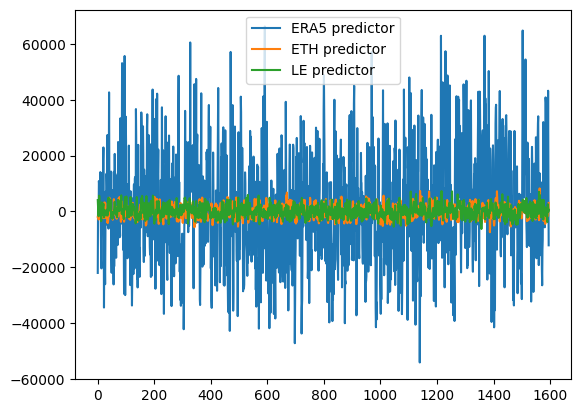

In [11]:
plt.plot(ERA5_z500.pseudo_pcs.isel(mode=0).values, label="ERA5 predictor")
plt.plot(eth_z500.pseudo_pcs.isel(mode=0).values[1710:1710+1596], label="ETH predictor")
plt.plot(ds_z500.pseudo_pcs.isel(mode=0).values[1710:1710+1596], label="LE predictor")
plt.legend()
#plt.plot(eth_predictors[:,0][1710:1710+1596])

## Fit Linear Model

0.90820444 1.3471472
X: torch.Size([429210, 1001])
y: torch.Size([429210])
X_val: torch.Size([47690, 1001])
y_val: torch.Size([47690])
X test eth: torch.Size([14307, 1001])


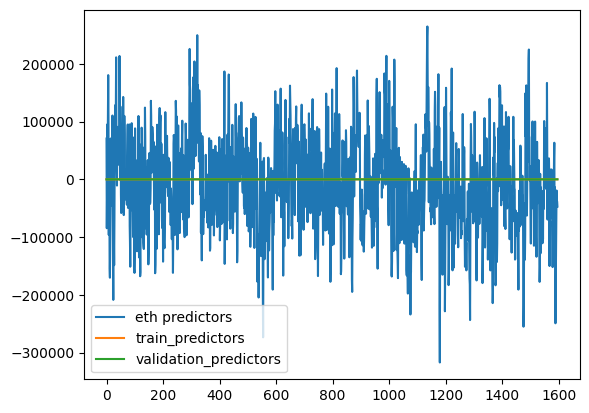

In [16]:
importlib.reload(ut)
# calculate domain (GER) TREFHT mean values
trefht_le_ger_mean = ut.get_ger_1d_data(ds_trefht.TREFHT)
#trefht_test_ger_mean = ut.get_ger_1d_data(ERA5_trefht.TREFHT)
eth_ger_mean = ut.get_ger_1d_data(eth_trefht.TREFHT)

# calculate GER spat mean
# standardize predictors
###
## train
predictors_combined_le = ds_z500.pseudo_pcs.values
train_predictors, train_predictors_mean, train_predictors_std = ut.standardize_numpy(predictors_combined_le[:90*4769, :])
print(train_predictors_mean[0,-1], train_predictors_std[0,-1])
X_torch = torch.from_numpy(train_predictors)
y_torch = torch.from_numpy(trefht_le_ger_mean.values)[:90*4769]

## validation
validation_predictors, _, _ = ut.standardize_numpy(predictors_combined_le[90*4769:, :], train_predictors_mean, train_predictors_std)
X_val_torch = torch.from_numpy(validation_predictors)
y_val_torch = torch.from_numpy(trefht_le_ger_mean.values)[90*4769:]

## test
#test_predictors, _, _ = ut.standardize_numpy(eth_z500.pseudo_pcs.values, train_predictors_mean, train_predictors_std)
#test_predictors_dummy, _, _ = ut.standardize_numpy(ERA5_z500.pseudo_pcs.values, train_predictors_mean, train_predictors_std)

#test_predictors[:,-1] = test_predictors_dummy[:,-1]
#x_test_torch = torch.from_numpy(test_predictors)

## eth
eth_predictors, _, _ = ut.standardize_numpy(eth_z500.pseudo_pcs.values, train_predictors_mean, train_predictors_std)
x_eth_torch = torch.from_numpy(eth_predictors)

print("X:", X_torch.shape)
print("y:", y_torch.shape)

print("X_val:", X_val_torch.shape)
print("y_val:", y_val_torch.shape)

print("X test eth:", x_eth_torch.shape)


#plt.plot(test_predictors[:,0])
plt.plot(eth_predictors[:,0][1710:1710+1596], label="eth predictors")
plt.plot(train_predictors[:,0][1710:1710+1596], label = "train_predictors")
plt.plot(validation_predictors[:,0][1710:1710+1596], label = "validation_predictors")

plt.legend()

In [13]:
# fit linear model

# excluding fGMT predictor
#X = X_torch[:, :100].float()

# including fGMT predictor
X = torch.cat([X_torch[:, :100], X_torch[:, -1:].clone()], dim=1)
 
y = y_torch[:].float()


print(X.shape)
# Add bias column
X_aug = torch.cat([X, torch.ones(X.shape[0], 1)], dim=1)

# Solve min ||X w - y||
w = torch.linalg.lstsq(X_aug, y).solution

weights = w[:-1]
bias = w[-1]


torch.Size([429210, 101])


In [79]:
# ridge regression
# Ridge regression (L2-regularized least squares) in PyTorch, closed-form

import torch

# excluding fGMT predictor
# X = X_torch[:, :100].float()

# including fGMT predictor
X = torch.cat([X_torch[:, :100], X_torch[:, -1:].clone()], dim=1).float()
y = y_torch.float()

print(X.shape)

# Add bias column
X_aug = torch.cat([X, torch.ones(X.shape[0], 1, device=X.device, dtype=X.dtype)], dim=1)

# Ridge strength
lam = 1e-1  # tune this

# Solve (X^T X + lam * I) w = X^T y
# Typically do NOT regularize the bias term:
p = X_aug.shape[1]
I = torch.eye(p, device=X.device, dtype=X.dtype)
I[-1, -1] = 0.0  # do not penalize bias

A = X_aug.T @ X_aug + lam * I
b = X_aug.T @ y

w = torch.linalg.solve(A, b)

weights = w[:-1]
bias = w[-1]


torch.Size([429210, 101])


<class 'torch.Tensor'>
Test RMSE: 1.0840032579571848
<xarray.DataArray 'TREFHT' (time: 1596)> Size: 6kB
array([-0.83358026,  0.62808657,  1.0674275 , ...,  6.8428826 ,
        3.3082118 , -0.3756212 ], shape=(1596,), dtype=float32)
Coordinates:
  * time     (time) object 13kB 1940-06-02 11:30:00 ... 2023-08-31 11:30:00
ERA5 Correlation: 0.9123934834604671


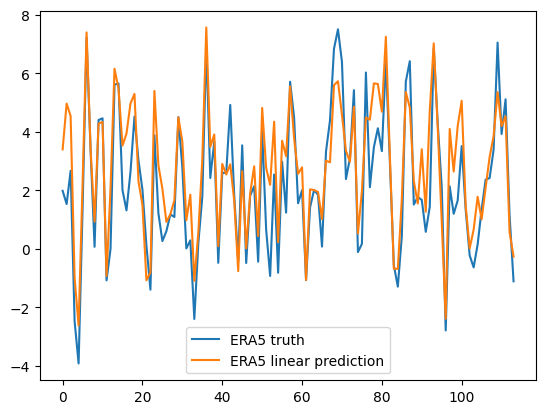

In [14]:
# apply model to validation data

# excluding fGMT
#test_predictors = x_test_torch[:, :100]

# including fGMT
test_predictors = torch.cat([x_test_torch[:, :100], x_test_torch[:, -1:].clone()],dim=1)

## including standardized fGMT predictor from ETH data
#test_predictors = torch.cat([x_test_torch[:, :100], x_eth_torch[1710:(1710+1596), -1:].clone()],dim=1)


y_pred_test = test_predictors.float() @ weights + bias
print(type(y_pred_test))
# evaluation
mse = torch.mean((y_pred_test - torch.from_numpy(trefht_test_ger_mean.values)) ** 2)
rmse = torch.sqrt(mse)
print("Test RMSE:", rmse.item())

# create xarray from predictions

y_pred_test_xr = xr.DataArray(y_pred_test.detach().numpy(),
                              dims = ["time"],
                              coords = {"time": trefht_test_ger_mean.time},
                              name="TREFHT")

#y_pred_test_xr.isel(time=slice(0,4769))
print(y_pred_test_xr)

############
### ERA5 ###
############
year_start = "2015"
year_end = "2020"
truth_to_plot = trefht_test_ger_mean.sel(time=slice(year_start,year_end)).values
time_to_plot = trefht_test_ger_mean.sel(time=slice(year_start,year_end)).time.values
test_preds_to_plot = y_pred_test_xr.sel(time=slice(year_start,year_end)).values

#rolling_era5 = rolling_mean(truth_to_plot, 100)

plt.plot(range(time_to_plot.shape[0]), truth_to_plot, label = "ERA5 truth")
plt.plot(range(time_to_plot.shape[0]), test_preds_to_plot, label = "ERA5 linear prediction")
#plt.plot(rolling_era5, label = "ERA5 truth rolling mean")
plt.legend()

# compute pearson correlation

corr = np.corrcoef(trefht_test_ger_mean.values, y_pred_test_xr.values)[0, 1]
print("ERA5 Correlation:", corr)


<class 'torch.Tensor'>
Test RMSE: 1.0840032579571848
<xarray.DataArray 'TREFHT' (time: 1596)> Size: 6kB
array([-0.83358026,  0.62808657,  1.0674275 , ...,  6.8428826 ,
        3.3082118 , -0.3756212 ], shape=(1596,), dtype=float32)
Coordinates:
  * time     (time) object 13kB 1940-06-02 11:30:00 ... 2023-08-31 11:30:00
ERA5 Correlation: 0.9123934834604671


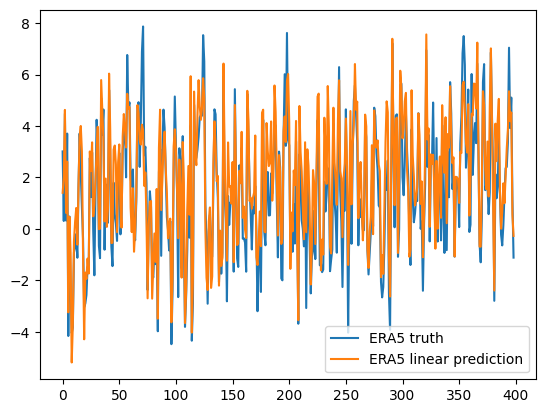

In [16]:
# apply model to test data (ERA5)

# excluding fGMT
#test_predictors = x_test_torch[:, :100]

# including fGMT
test_predictors = torch.cat([x_test_torch[:, :100], x_test_torch[:, -1:].clone()],dim=1)

## including standardized fGMT predictor from ETH data
#test_predictors = torch.cat([x_test_torch[:, :100], x_eth_torch[1710:(1710+1596), -1:].clone()],dim=1)


y_pred_test = test_predictors.float() @ weights + bias
print(type(y_pred_test))
# evaluation
mse = torch.mean((y_pred_test - torch.from_numpy(trefht_test_ger_mean.values)) ** 2)
rmse = torch.sqrt(mse)
print("Test RMSE:", rmse.item())

# create xarray from predictions

y_pred_test_xr = xr.DataArray(y_pred_test.detach().numpy(),
                              dims = ["time"],
                              coords = {"time": trefht_test_ger_mean.time},
                              name="TREFHT")

#y_pred_test_xr.isel(time=slice(0,4769))
print(y_pred_test_xr)

############
### ERA5 ###
############
year_start = "2000"
year_end = "2020"
truth_to_plot = trefht_test_ger_mean.sel(time=slice(year_start,year_end)).values
time_to_plot = trefht_test_ger_mean.sel(time=slice(year_start,year_end)).time.values
test_preds_to_plot = y_pred_test_xr.sel(time=slice(year_start,year_end)).values

#rolling_era5 = rolling_mean(truth_to_plot, 100)

plt.plot(range(time_to_plot.shape[0]), truth_to_plot, label = "ERA5 truth")
plt.plot(range(time_to_plot.shape[0]), test_preds_to_plot, label = "ERA5 linear prediction")
#plt.plot(rolling_era5, label = "ERA5 truth rolling mean")
plt.legend()

# compute pearson correlation

corr = np.corrcoef(trefht_test_ger_mean.values, y_pred_test_xr.values)[0, 1]
print("ERA5 Correlation:", corr)


Test RMSE: 1.2133806470856465
ETH Correlation: 0.9259845397134049


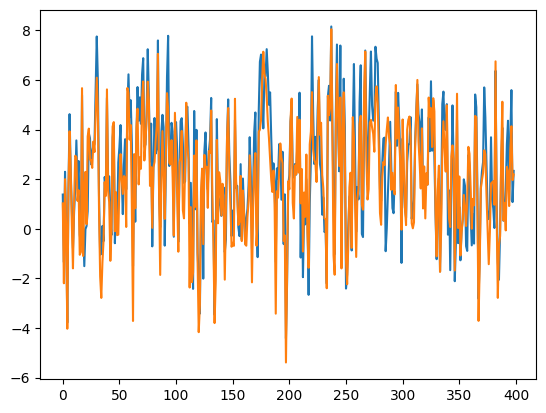

In [17]:
# apply model to ETH data

# excluding fGMT
#test_predictors_eth = x_eth_torch[:, :100]

# including fGMT
test_predictors_eth = torch.cat(
    [x_eth_torch[:, :100], x_eth_torch[:, -1:].clone()],
    dim=1
)
y_pred_eth = test_predictors_eth.float() @ weights + bias

# evaluation
mse = torch.mean((y_pred_eth - torch.from_numpy(eth_ger_mean.values)) ** 2)
rmse = torch.sqrt(mse)
print("Test RMSE:", rmse.item())

# create xarray from predictions

y_pred_eth_test_xr = xr.DataArray(y_pred_eth.detach().numpy(),
                              dims = ["time"],
                              coords = {"time": eth_ger_mean.time},
                              name="TREFHT")

y_pred_eth_test_xr

###########
### ETH ###
###########

#year_start = "2085"
#year_end = "2090"
truth_eth_to_plot = eth_ger_mean.isel(time=slice(0,4769)).sel(time=slice(year_start,year_end)).values
time_to_plot = eth_ger_mean.isel(time=slice(0,4769)).sel(time=slice(year_start,year_end)).time.values
test_eth_preds_to_plot = y_pred_eth_test_xr.isel(time=slice(0,4769)).sel(time=slice(year_start,year_end)).values

plt.plot(range(time_to_plot.shape[0]), truth_eth_to_plot)
plt.plot(range(time_to_plot.shape[0]), test_eth_preds_to_plot)

corr = np.corrcoef(eth_ger_mean.values, y_pred_eth_test_xr.values)[0, 1]
print("ETH Correlation:", corr)

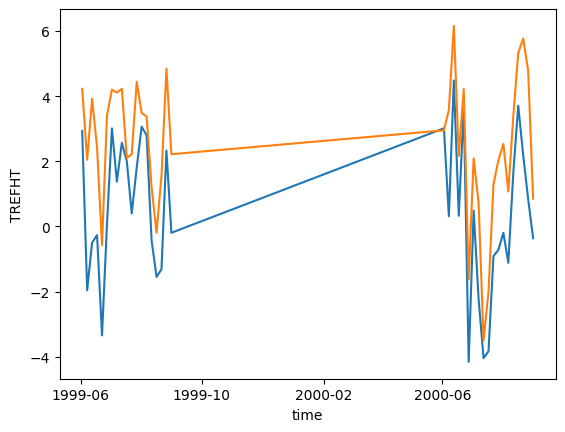

In [73]:
trefht_test_ger_mean.sel(time=slice("1999","2000")).plot()
y_pred_test_xr.sel(time=slice("1999","2000")).plot()

ERA5 Correlation: 0.9123948976277144


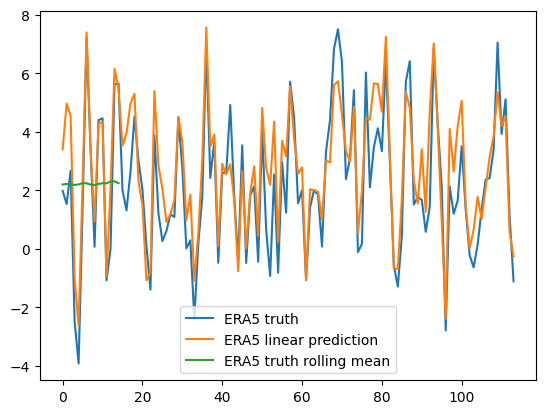

ETH Correlation: 0.9260602528498884


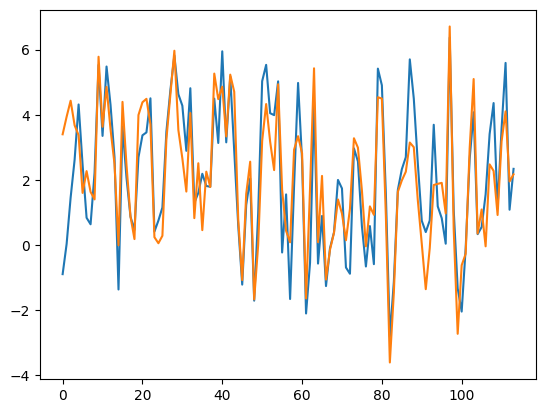

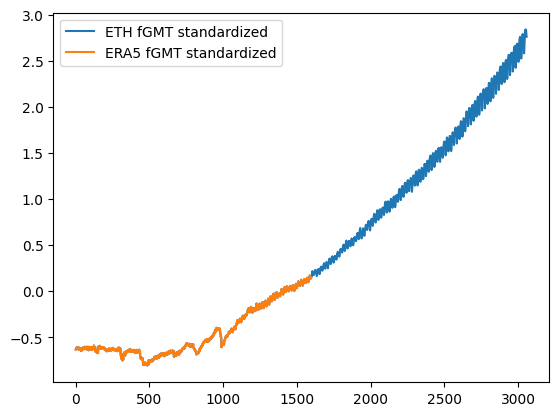

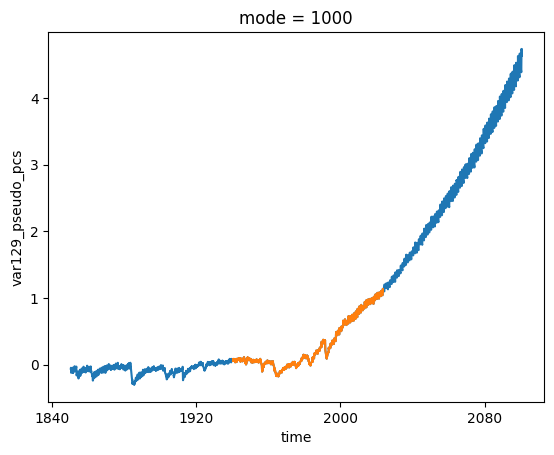

In [18]:
# compare fGMT predictors of ERA5 and ETH
plt.plot(x_eth_torch[:, -1:][:4769][1710:], label = "ETH fGMT standardized") # ok here something looks off
plt.plot(x_test_torch[:, -1:], label="ERA5 fGMT standardized")

plt.legend()
plt.show()

# xarray

eth_z500.pseudo_pcs.isel(time=slice(0,4769), mode=1000).plot()
ERA5_z500.pseudo_pcs.isel(mode=1000).plot()

In [95]:
#eth_z500.pseudo_pcs.isel(time=slice(0,4769)).sel(time=slice("1850","1939"))
eth_z500.pseudo_pcs.isel(time=slice(0,4769)).isel(time=slice(1710,4769))

<xarray.DataArray 'pseudo_pcs' (time: 3059, mode: 1001)> Size: 12MB
array([[-1.892682e+03,  1.584948e+03, -6.484280e+02, ..., -3.797698e-01,
         4.679123e-01,  5.612347e-02],
       [-1.468437e+03, -3.775421e+03, -2.309778e+03, ...,  1.876054e-01,
        -1.990559e-01,  6.721421e-02],
       [-1.906517e+03, -3.750360e+03, -2.179943e+03, ...,  1.223477e-01,
        -5.509589e-01,  7.882640e-02],
       ...,
       [ 6.162728e+02,  1.033608e+03,  3.060743e+03, ...,  4.068614e-01,
        -4.172783e-01,  4.657505e+00],
       [ 6.725012e+02, -4.212942e+02,  5.793282e+02, ..., -5.889958e-01,
        -6.816442e-01,  4.639620e+00],
       [ 5.940941e+02, -4.612968e+03,  1.121882e+03, ...,  4.204028e-01,
         1.881170e-02,  4.628327e+00]], shape=(3059, 1001), dtype=float32)
Coordinates:
  * time     (time) object 24kB 1940-06-02 00:00:00 ... 2100-08-31 00:00:00
  * mode     (mode) int64 8kB 0 1 2 3 4 5 6 7 ... 994 995 996 997 998 999 1000
Attributes:
    long_name:              Z500_pseudo_pcs
    Ensemble_member_order:  [ 0  0  0 ... 99 99 99]

## ERA5 predictors

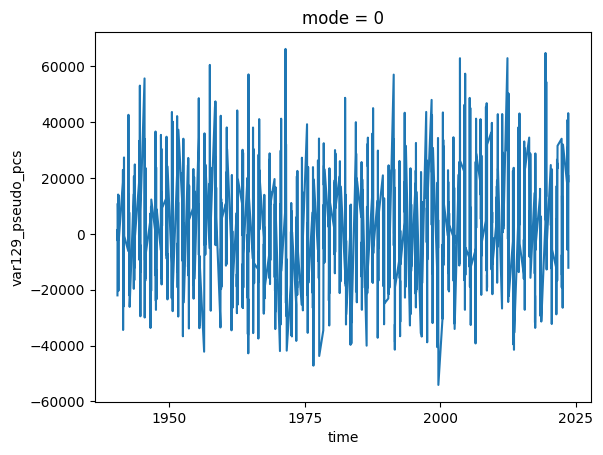

In [25]:
ERA5_z500.pseudo_pcs.sel(mode=0).plot()

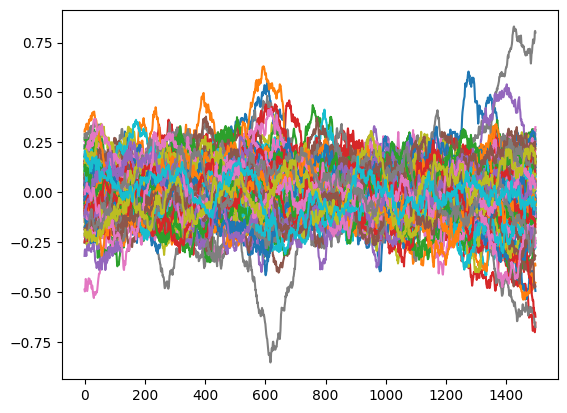

In [37]:
def rolling_mean(x, window):
    x = np.asarray(x, dtype=float)
    cumsum = np.cumsum(np.insert(x, 0, 0.0))
    return (cumsum[window:] - cumsum[:-window]) / window


for i in range(100):
    data_to_plot = test_predictors[:,i]
    rolling = rolling_mean(data_to_plot, 100)
    
    #type(data_to_plot)
    #plt.plot(data_to_plot)
    plt.plot(rolling)
plt.show()